# Wooting key-travel analysis

Loads CSVs produced by the `key_recorder` binary (under `tools/key_recorder/`) and turns them into pandas DataFrames + plots.

Each CSV contains 8000 samples at ~8 kHz: **1000 pre-trigger + 7000 post-trigger**, where the trigger is the first sample where depth crossed 0.5 upward. The trigger is at `sample_idx == 1000` and `t_us_relative_to_trigger == 0` (or close to it; `t_us_relative_to_trigger` is the actual elapsed time from the recorder's perspective).

Filenames are `key_0xNN_YYYYMMDDTHHMMSSmmm.csv` so the HID code and timestamp are recoverable.

## Usage
1. Run the recorder: `cd tools/key_recorder && cargo run --release -- --output-dir /tmp/keyrecord`
2. Press the keys you want to analyze.
3. The notebook's `TRACE_DIR` defaults to `/tmp/keyrecord` — adjust below if you used a different path.
4. Run all cells.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRACE_DIR = Path('/tmp/keyrecord')
PRE_SAMPLES = 1000
POST_SAMPLES = 7000
TOTAL_SAMPLES = PRE_SAMPLES + POST_SAMPLES

# Common HID-code -> human label, lifted from the 60HE v2 YAML.
HID_LABELS: dict[int, str] = {
    0x04: 'A', 0x05: 'B', 0x06: 'C', 0x07: 'D', 0x08: 'E', 0x09: 'F',
    0x0A: 'G', 0x0B: 'H', 0x0C: 'I', 0x0D: 'J', 0x0E: 'K', 0x0F: 'L',
    0x10: 'M', 0x11: 'N', 0x12: 'O', 0x13: 'P', 0x14: 'Q', 0x15: 'R',
    0x16: 'S', 0x17: 'T', 0x18: 'U', 0x19: 'V', 0x1A: 'W', 0x1B: 'X',
    0x1C: 'Y', 0x1D: 'Z',
    0x1E: '1', 0x1F: '2', 0x20: '3', 0x21: '4', 0x22: '5', 0x23: '6',
    0x24: '7', 0x25: '8', 0x26: '9', 0x27: '0',
    0x28: 'Enter', 0x29: 'Esc', 0x2A: 'Bksp', 0x2B: 'Tab', 0x2C: 'Space',
    0x2D: '-', 0x2E: '=', 0x2F: '[', 0x30: ']', 0x31: '\\',
    0x33: ';', 0x34: "'", 0x35: '`',
    0x36: ',', 0x37: '.', 0x38: '/',
}

_FNAME_RE = re.compile(r'^key_0x([0-9A-Fa-f]+)_(\d{8}T\d{9})\.csv$')

In [2]:
@dataclass(frozen=True)
class Trace:
    path: Path
    hid_code: int
    label: str
    captured_at: str  # raw filename timestamp
    df: pd.DataFrame  # columns: sample_idx, t_us_relative_to_trigger, depth

    @property
    def t_ms(self) -> pd.Series:
        return self.df['t_us_relative_to_trigger'] / 1000.0


def parse_filename(name: str) -> tuple[int, str] | None:
    m = _FNAME_RE.match(name)
    if not m:
        return None
    return int(m.group(1), 16), m.group(2)


def load_trace(path: Path) -> Trace:
    parsed = parse_filename(path.name)
    if parsed is None:
        raise ValueError(f'unrecognized filename: {path.name}')
    hid_code, captured_at = parsed
    df = pd.read_csv(path)
    label = HID_LABELS.get(hid_code, f'0x{hid_code:02X}')
    return Trace(path=path, hid_code=hid_code, label=label, captured_at=captured_at, df=df)


def load_session(folder: Path = TRACE_DIR) -> list[Trace]:
    folder = Path(folder)
    if not folder.is_dir():
        raise FileNotFoundError(folder)
    return sorted(
        (load_trace(p) for p in folder.glob('key_*.csv')),
        key=lambda t: (t.hid_code, t.captured_at),
    )


traces = load_session()
print(f'loaded {len(traces)} traces from {TRACE_DIR}')
for t in traces[:10]:
    print(f'  {t.label:>5}  HID=0x{t.hid_code:02X}  {t.captured_at}  ({t.path.name})')

loaded 19 traces from /tmp/keyrecord
      A  HID=0x04  20260505T155653649  (key_0x04_20260505T155653649.csv)
      B  HID=0x05  20260505T155706416  (key_0x05_20260505T155706416.csv)
      C  HID=0x06  20260505T155704723  (key_0x06_20260505T155704723.csv)
      D  HID=0x07  20260505T155654825  (key_0x07_20260505T155654825.csv)
      F  HID=0x09  20260505T155655373  (key_0x09_20260505T155655373.csv)
      G  HID=0x0A  20260505T155655890  (key_0x0A_20260505T155655890.csv)
      H  HID=0x0B  20260505T155656458  (key_0x0B_20260505T155656458.csv)
      J  HID=0x0D  20260505T155657033  (key_0x0D_20260505T155657033.csv)
      K  HID=0x0E  20260505T155657658  (key_0x0E_20260505T155657658.csv)
      M  HID=0x10  20260505T155707985  (key_0x10_20260505T155707985.csv)


## Single trace plot
Pick a trace and look at its depth vs. time. The vertical dashed line is the trigger sample (depth first crossed 0.5 going up).

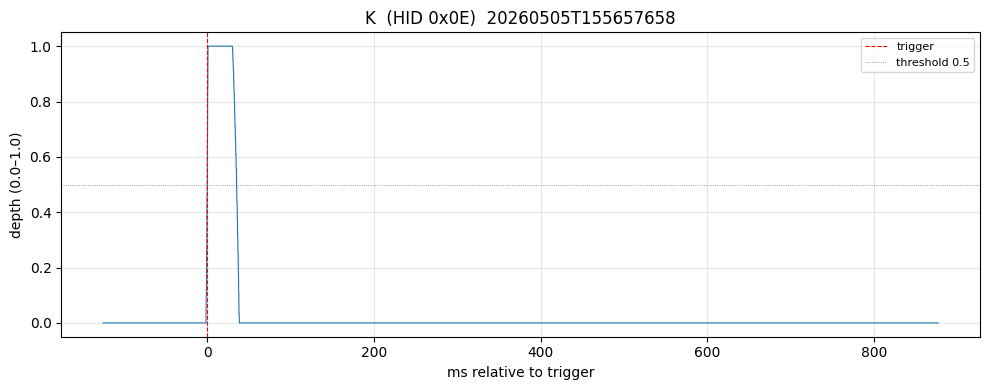

In [3]:
def plot_trace(trace: Trace, ax: plt.Axes | None = None) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.plot(trace.t_ms, trace.df['depth'], lw=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=0.8, label='trigger')
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.6, label='threshold 0.5')
    ax.set_xlabel('ms relative to trigger')
    ax.set_ylabel('depth (0.0–1.0)')
    ax.set_title(f'{trace.label}  (HID 0x{trace.hid_code:02X})  {trace.captured_at}')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    return ax


if traces:
    plot_trace(traces[8])
    plt.tight_layout()
    plt.show()

## All presses for one key, overlaid
Useful for seeing press-to-press variability.

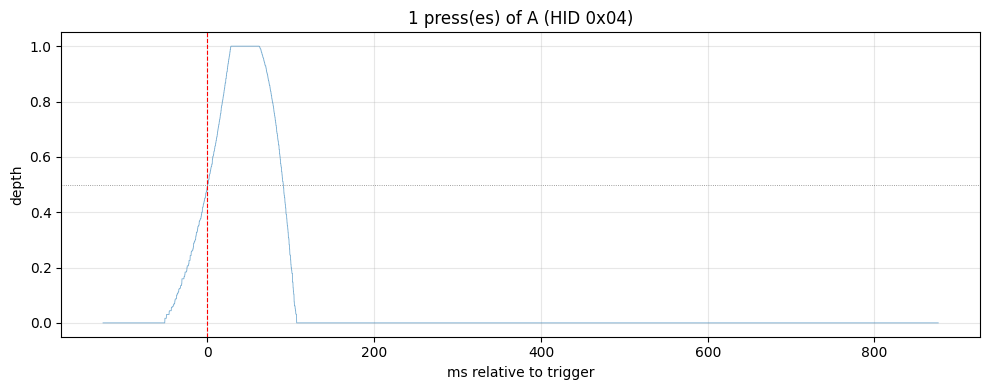

In [4]:
def plot_overlay(
    traces_for_key: Iterable[Trace],
    title: str | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    traces_list = list(traces_for_key)
    for t in traces_list:
        ax.plot(t.t_ms, t.df['depth'], lw=0.6, alpha=0.6)
    ax.axvline(0, color='red', linestyle='--', lw=0.8)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.6)
    ax.set_xlabel('ms relative to trigger')
    ax.set_ylabel('depth')
    if title is None and traces_list:
        title = f'{len(traces_list)} press(es) of {traces_list[0].label} (HID 0x{traces_list[0].hid_code:02X})'
    ax.set_title(title or 'overlay')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    return ax


from collections import defaultdict

by_key: dict[int, list[Trace]] = defaultdict(list)
for t in traces:
    by_key[t.hid_code].append(t)

if by_key:
    most_pressed_hid = max(by_key, key=lambda k: len(by_key[k]))
    plot_overlay(by_key[most_pressed_hid])
    plt.tight_layout()
    plt.show()

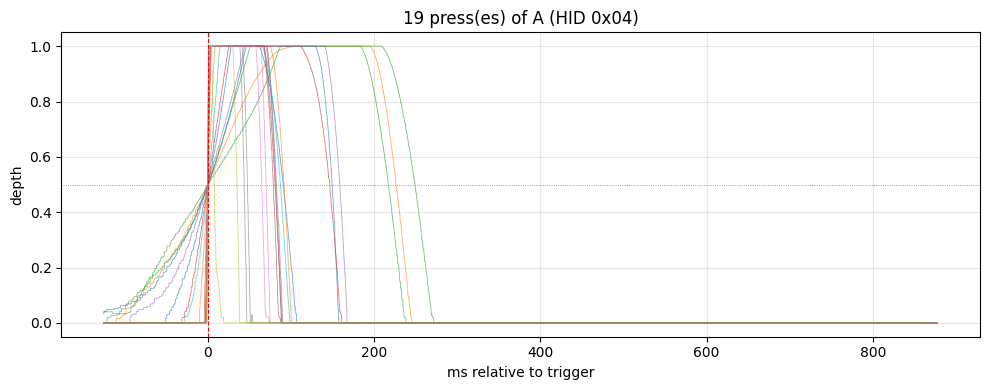

In [5]:
plot_overlay(traces)
plt.tight_layout()
plt.show()

## Noise floor characterisation
Pre-trigger samples should be 0 (key not pressed). Anything non-zero in there is sensor noise — useful for picking velocity thresholds.

In [6]:
def noise_stats(trace: Trace, n_pre: int = PRE_SAMPLES) -> dict[str, float]:
    pre = trace.df.iloc[:n_pre]['depth']
    return {
        'mean': float(pre.mean()),
        'std': float(pre.std()),
        'max': float(pre.max()),
        'min': float(pre.min()),
        'p95': float(pre.quantile(0.95)),
        'p99': float(pre.quantile(0.99)),
    }


def session_noise_summary(traces: list[Trace]) -> pd.DataFrame:
    rows = []
    for t in traces:
        s = noise_stats(t)
        rows.append(
            {
                'label': t.label,
                'hid': f'0x{t.hid_code:02X}',
                'captured_at': t.captured_at,
                **s,
            }
        )
    return pd.DataFrame(rows)


if traces:
    summary = session_noise_summary(traces)
    summary

## Velocity-curve diagnostics
Time from `T_arm = 0.15` to `T_trigger = 0.50` is what the MPE profile uses to compute velocity. Plot the dt distribution across all presses.

measured dt for 12 of 13 traces


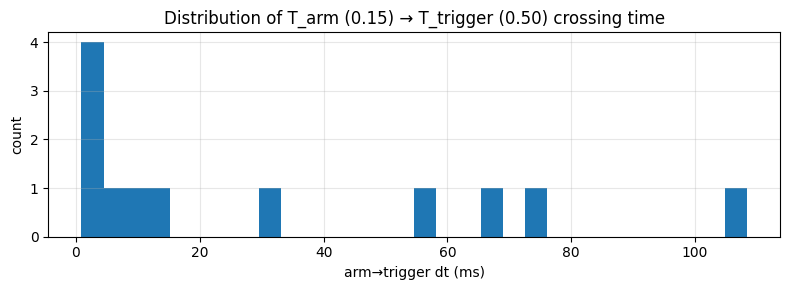

In [7]:
T_ARM = 0.15
T_TRIGGER = 0.50


def measure_arm_to_trigger(trace: Trace) -> float | None:
    """Find the upward crossings of T_arm and T_trigger and return dt (ms).

    Returns None if the trace doesn't cleanly contain both crossings.
    """
    df = trace.df
    depths = df['depth'].to_numpy()
    # Last index where depth < T_arm before the trigger at index PRE_SAMPLES.
    pre_window = depths[: PRE_SAMPLES + 1]
    arm_idx = None
    for i in range(len(pre_window) - 1, 0, -1):
        if pre_window[i - 1] < T_ARM <= pre_window[i]:
            arm_idx = i
            break
    trig_idx = None
    for i in range(len(depths) - 1):
        if depths[i] < T_TRIGGER <= depths[i + 1]:
            trig_idx = i + 1
            break
    if arm_idx is None or trig_idx is None or trig_idx <= arm_idx:
        return None
    t_arm = df.iloc[arm_idx]['t_us_relative_to_trigger']
    t_trig = df.iloc[trig_idx]['t_us_relative_to_trigger']
    return float(t_trig - t_arm) / 1000.0  # ms


if traces:
    dts = []
    for t in traces:
        dt = measure_arm_to_trigger(t)
        if dt is not None:
            dts.append({'label': t.label, 'hid': f'0x{t.hid_code:02X}', 'dt_ms': dt})
    dts_df = pd.DataFrame(dts)
    print(f'measured dt for {len(dts_df)} of {len(traces)} traces')
    fig, ax = plt.subplots(figsize=(8, 3))
    if not dts_df.empty:
        ax.hist(dts_df['dt_ms'], bins=30)
    ax.set_xlabel('arm→trigger dt (ms)')
    ax.set_ylabel('count')
    ax.set_title('Distribution of T_arm (0.15) → T_trigger (0.50) crossing time')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    dts_df.describe()

## Raw access for further analysis
All traces are loaded into the `traces` list above. Useful starters:

```python
# Stack all traces into one DataFrame with a multi-index.
all_df = pd.concat(
    [t.df.assign(hid=t.hid_code, label=t.label, captured_at=t.captured_at)
     for t in traces],
    ignore_index=True,
)

# Find the deepest peak of each press.
peaks = pd.DataFrame([
    {'label': t.label, 'hid': t.hid_code, 'peak': t.df['depth'].max()}
    for t in traces
])
```

In [9]:
# Stack all traces into one DataFrame with a multi-index.
all_df = pd.concat(
    [t.df.assign(hid=t.hid_code, label=t.label, captured_at=t.captured_at)
     for t in traces],
    ignore_index=True,
)

# Find the deepest peak of each press.
peaks = pd.DataFrame([
    {'label': t.label, 'hid': t.hid_code, 'peak': t.df['depth'].max()}
    for t in traces
])

In [10]:
all_df

,sample_idx,t_us_relative_to_trigger,depth,hid,label,captured_at
0,0,-2599262,0.0,4,A,20260505T152039299
1,1,-2599262,0.0,4,A,20260505T152039299
2,2,-2599262,0.0,4,A,20260505T152039299
3,3,-2599262,0.0,4,A,20260505T152039299
4,4,-2599262,0.0,4,A,20260505T152039299
...,...,...,...,...,...,...
103995,7995,875832,0.0,40,Enter,20260505T152036787
103996,7996,875957,0.0,40,Enter,20260505T152036787
103997,7997,876082,0.0,40,Enter,20260505T152036787
103998,7998,876207,0.0,40,Enter,20260505T152036787
